In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandapower as pp
import sympy as sp
from sympy.physics.vector import dynamicsymbols
from sympy.physics.mechanics import init_vprinting
import scipy.integrate as spi
from scipy.integrate import solve_ivp 

import helper_functions.optimal_controller as oc

# to get test system
import pandas as pd
from pypower.api import case14, runpf, printpf, makeYbus
from pypower.idx_bus import *
from pypower.idx_brch import *
from pypower.idx_gen import *

# Text display
from IPython.display import display, HTML, Math

# Initialize pretty printing with MathJax
init_vprinting(use_latex="mathjax")

# Helper Functions

In [2]:
def convert_rx_to_gb(r,x,positive_b_inductor=True):
    # We define default z = r + jx and y = g - jb
    # Therefore x>0 -> b>0
    denom = r**2 + x**2
    if positive_b_inductor:
        return r/denom, x/denom
    else:
        return r/denom, -x/denom

def convert_gb_to_rx(g, b, positive_b_inductor=True):
    denom = g**2 + b**2
    if positive_b_inductor:
        return g/denom, b/denom
    else:
        return g/denom, -b/denom
    
def convert_complexy_to_ydq(complexy):
    g = complexy.real
    b = -complexy.imag
    return np.array([[g, b],[-b,g]])

def convert_complexY_to_Ydq(complexY):
    n = complexY.shape[0]
    Ydq = np.zeros((2*n, 2*n))
    for i in range(n):
        for k in range(n):
            Ydq[2*i:2*i + 2, 2*k:2*k + 2] = convert_complexy_to_ydq(complexY[i,k])
    return Ydq


# 1. Load 14 bus test system and run powerflow

In [3]:
net14 = case14()
base_mva = net14["baseMVA"]
# Initialize "inverters" at non-zero power before solving powerflow
net14["gen"][:,PG] = np.array([60,50,50,50,50])

# Uncomment if we need nonzero loads everywhere
# zero_loads = np.where(net14["bus"][:,PD] == 0)
# net14["bus"][zero_loads, PD] = 5.0

# Find equilibrium point (run power flow) to initialize simulation
pf_result, success = runpf(net14)

PYPOWER Version 5.1.18, 10-Apr-2025 -- AC Power Flow (Newton)


Newton's method power flow converged in 3 iterations.

Converged in 0.01 seconds
|     System Summary                                                           |

How many?                How much?              P (MW)            Q (MVAr)
---------------------    -------------------  -------------  -----------------
Buses             14     Total Gen Capacity     772.4         -52.0 to 148.0
Generators         5     On-line Capacity       772.4         -52.0 to 148.0
Committed Gens     5     Generation (actual)    261.3              41.3
Loads             11     Load                   259.0              73.5
  Fixed           11       Fixed                259.0              73.5
  Dispatchable     0       Dispatchable           0.0 of 0.0        0.0
Shunts             1     Shunt (inj)             -0.0              21.3
Branches          20     Losses (I^2 * Z)         2.31             13.68
Transformers       3     Branch 

# 2 Construct Ybus Matrix

### Choose inverter filter parameters

In [4]:
# np.random.seed(1024) # for reproducibility
filter_xs = np.ones(5) * 0.1 # np.random.uniform(0.08, 0.12, 5) # in per unit
filter_rs = np.ones(5) * 0.01 # np.random.uniform(0.08, 0.2,5) * filter_xs # in per unit, slightly larger resistances than reactances
inverter_bus_ids = np.array(net14["gen"][:,GEN_BUS],dtype=int)
print(inverter_bus_ids, filter_xs, filter_rs)

# Convert filter impedances to admittances
# NOTE: pypower defines b>0 as capacitance (y=g+jb), but we define b>0 as inductance (y=g-jb)
filter_gs, filter_bs = convert_rx_to_gb(filter_rs, filter_xs, positive_b_inductor=True)

[1 2 3 6 8] [0.1 0.1 0.1 0.1 0.1] [0.01 0.01 0.01 0.01 0.01]


### Loop through buses and branches

In [5]:
nb = net14["bus"].shape[0]
nbr = net14["branch"].shape[0]
Ybus = np.zeros((nb,nb),dtype=complex)

# Add self-admittances (diagonal-only elements)
bus_shunts = (net14["bus"][:,GS] + net14["bus"][:,BS]*1j)/base_mva # pypower uses y=g+jb
inverter_shunts = np.zeros(nb,dtype=complex)
inverter_shunts[inverter_bus_ids - 1] = filter_gs - filter_bs*1j
bus_loads = (pf_result["bus"][:,PD] - pf_result["bus"][:,QD] * 1j)/ (base_mva * pf_result["bus"][:,VM] ** 2) # Convert PD and QD to per unit then divide by squared Vm

#np.fill_diagonal(Ybus, bus_shunts + inverter_shunts + bus_loads)
np.fill_diagonal(Ybus, bus_shunts + bus_loads)

# Add mutual admittances (add to diagonals and subtract from off-diagonals)
for i in range(nbr):
    # Ignore line charging susceptance
    from_bus = int(net14["branch"][i, F_BUS])
    to_bus = int(net14["branch"][i,T_BUS])
    g, b = convert_rx_to_gb(net14["branch"][i, BR_R], net14["branch"][i, BR_X], positive_b_inductor=True) # already in pu
    branch_admittance = g - b * 1j
    # Add negative branch admittances to off-diagonals
    Ybus[from_bus - 1, to_bus - 1] = -branch_admittance
    Ybus[to_bus - 1, from_bus - 1] = -branch_admittance

    # Add branch admittances to diagonals
    Ybus[from_bus - 1, from_bus - 1] += branch_admittance
    Ybus[to_bus - 1, to_bus - 1] += branch_admittance

# Reorder Ybus rows for Kron Reduction
inv_idx = inverter_bus_ids - 1 # rows we want first
elim_nodes = np.setdiff1d(range(nb), inv_idx)
new_order = np.hstack((inv_idx, elim_nodes))

# Swap rows
Ybus = Ybus[new_order, :]

# Swap columns
Ybus = Ybus[:,new_order]

# Do Kron Reduction
n_keep = len(inv_idx)
K = Ybus[:n_keep, :n_keep]
L = Ybus[:n_keep, n_keep:]
LT = Ybus[n_keep:, :n_keep]
M = Ybus[n_keep:, n_keep:]

Ybus_KRON = K - L @ np.linalg.inv(M) @ LT

# Convert to real dq matrix

Ybus_KRONdq = convert_complexY_to_Ydq(Ybus_KRON)
Zbus_KRONdq = np.linalg.inv(Ybus_KRONdq)

# Also find the admittance/impedances matrices to convert inverter currents to inverter voltages knowing network voltages
Z_filters = np.diag(filter_rs + filter_xs * 1j)
Y_filtersdq = convert_complexY_to_Ydq(np.linalg.inv(Z_filters))
Z_filtersdq = np.linalg.inv(Y_filtersdq)

## 3 Dynamic Simulations

In [6]:
def calculate_P_network(Iinvs, Vinvs, perunit=True):
    n = int(len(Iinvs) / 2)
    if perunit:
        return np.sum(Iinvs.reshape(n,2) * Vinvs.reshape(n,2), axis=1)
    return 3 * np.sum(Iinvs.reshape(n,2) * Vinvs.reshape(n,2), axis=1)

def calculate_Q_network(Iinvs, Vinvs, perunit=True):
    n = int(len(Iinvs) / 2)
    J = np.array([[0,1],[-1,0]])
    if perunit:
        return np.sum(Iinvs.reshape(n,2) * (Vinvs.reshape(n,2) @ J), axis=1)
    return 3 * np.sum(Iinvs.reshape(n,2) * (Vinvs.reshape(n,2) @ J), axis=1)

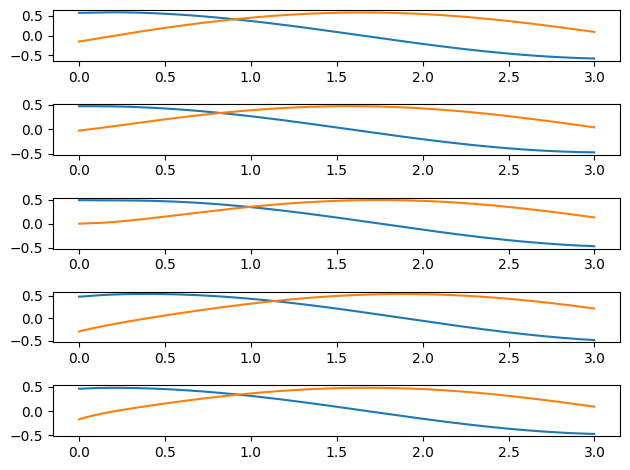

In [13]:
# NOTE: Use Ybus with no filters or loads baked in for power flow. Then find Iinv = Ipfresult - Iload
# Then use Ybus with filters and loads baked in for dynamics to see how changing Iinv impacts Vnetwork which then adjusts actual Iinv
# See page 175 of Steven Low's book

endtime = 3
dt = 1e-3
ts = np.arange(0, endtime, dt)

omega = 2*np.pi*60 # just used for converting X to L assuming constant impedance
rho = 0.0001
alpha = 0.1

Vgs = np.zeros((len(ts),n_keep*2))
Iinvs = np.zeros((len(ts),n_keep*2))
Vinvs = np.zeros((len(ts),n_keep*2))
Ps = np.zeros((len(ts),n_keep))
Qs = np.zeros((len(ts),n_keep))

# Initialize Vg0 from power flow and solve for the rest
Vg0_mags = pf_result["bus"][inv_idx,VM] # voltage magnitudes
Vg0_angles = np.deg2rad(pf_result["bus"][inv_idx,VA]) # pypower angle converted to radians
Vgs[0,:] = np.vstack((Vg0_mags * np.cos(Vg0_angles),Vg0_mags * np.sin(Vg0_angles))).T.flatten() # in dq
Iinvs[0,:] = Ybus_KRONdq @ Vgs[0,:] # Approximate currents as I = Y_KRON V_pf
Vinvs[0,:] = Vgs[0,:] + Iinvs[0,:] @ Z_filtersdq.T
Ps[0,:] = calculate_P_network(Iinvs[0,:], Vinvs[0,:])
Qs[0,:] = calculate_Q_network(Iinvs[0,:], Vinvs[0,:])

# Set the setpoints equal to the initial values
# TODO: CHANGE to a mix of PQ and PV2 inverters
inverter_setpoints = np.vstack((Ps[0,:],np.linalg.norm(Vinvs[0,:].reshape(5,2),axis=1))).T
#inverter_setpoints *= 2
inverter_varnames = np.array([["P",r"$V^2$"],["P",r"$V^2$"],["P",r"$V^2$"],["P",r"$V^2$"],["P",r"$V^2$"]]) # variables corresponding to setpoints in above array
inverter_mag_limits = np.ones(n_keep) # all limited to 1 pu? check what this value should be - possibly smaller since baseMVA is large
# have filter_rs and filter_xs from before


for k,t in enumerate(ts[:-1]):
    # TODO: Model load disturbance and some start time (perturb Y matrix, then recalculate Z matrix)
    xpluses = np.zeros(n_keep*2)
    for inv in range(n_keep):
        xplus = oc.oc_single_iteration(inverter_setpoints[inv,:], inverter_varnames[inv,:], Iinvs[k,2*inv:2*inv+2], 
                                       filter_rs[inv], filter_xs[inv]/omega, Vgs[k,2*inv:2*inv+2], inverter_mag_limits[inv], omega,
                                        rho=rho, alpha=alpha,
                                        perunit=True)
        xpluses[2*inv:2*inv+2] = xplus
    # Calculate new values across network
    Iinvs[k+1, :] = xpluses
    Vgs[k+1, :] = Zbus_KRONdq @ Iinvs[k+1, :]
    Vinvs[k+1, :] = Vgs[k+1,:] + Iinvs[k+1,:] @ Z_filtersdq.T
    Ps[k+1,:] = calculate_P_network(Iinvs[k+1,:], Vinvs[k+1,:])
    Qs[k+1,:] = calculate_Q_network(Iinvs[k+1,:], Vinvs[k+1,:])

# TODO: Calculate and plot Vmag, angle, and frequency over time for inverters and network nodes
fig = plt.figure()
for inv in range(n_keep):
    plt.subplot(n_keep, 1, inv+1)
    plt.plot(ts, Iinvs[:,2*inv],label="Id")
    plt.plot(ts, Iinvs[:,2*inv + 1],label="Iq")

plt.tight_layout()

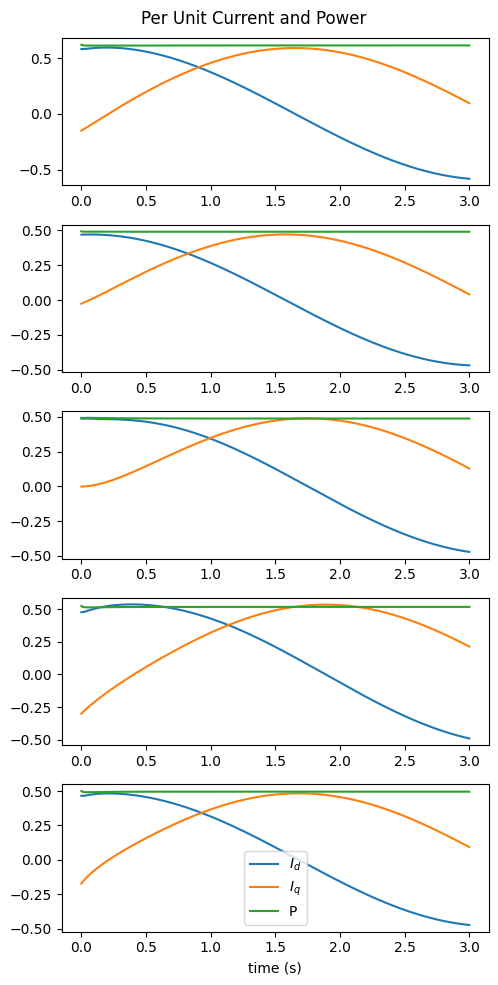

In [14]:
fig = plt.figure(figsize=(5,10))
for inv in range(n_keep):
    ax = plt.subplot(n_keep, 1, inv+1)
    plt.plot(ts, Iinvs[:,2*inv],label="$I_d$")
    plt.plot(ts, Iinvs[:,2*inv + 1],label="$I_q$")
    plt.plot(ts, Ps[:,inv],label="P")
    #plt.plot(ts, Qs[:,inv],label="Q")
ax.legend()
ax.set_xlabel("time (s)")
fig.suptitle("Per Unit Current and Power")
plt.tight_layout()